# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Febri Nur Ardian Syah
- **Email:** febriardiansyah737@gmail.com
- **ID Dicoding:** febri18

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Berdasarkan performa pendapatan selama tahun 2017, kategori produk manakah yang terbukti paling laris dan patut dijadikan prioritas utama perusahaan untuk persediaan di periode selanjutnya?
- **Pertanyaan 2:** Berdasarkan pola transaksi pelanggan selama tahun 2017, kapankah waktu yang paling optimal, dan metode pembayaran apakah yang sebaiknya diprioritaskan oleh perusahaan dalam merancang kampanye promosi berikutnya?"
- **Pertanyaan 3:** Berdasarkan data demografi transaksi selama tahun 2017, negara bagian (state) manakah yang menyumbang jumlah pelanggan dan total pendapatan tertinggi, yang dapat dijadikan prioritas utama untuk ekspansi pemasaran dan layanan logistik perusahaan?

## Import Semua Packages/Library yang Digunakan

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

## Data Wrangling

### Gathering Data

#### Load df ...

In [4]:
# Memuat tabel-tabel yang dibutuhkan
orders_df = pd.read_csv("olist_orders_dataset.csv")
order_items_df = pd.read_csv("olist_order_items_dataset.csv")
order_payments_df = pd.read_csv("olist_order_payments_dataset.csv")
products_df = pd.read_csv("olist_products_dataset.csv")
customers_df = pd.read_csv("olist_customers_dataset.csv")

orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


**Insight:** (Opsional)
**Insight:**
* Telah berhasil memuat 5 dataset utama yang dibutuhkan untuk analisis, yaitu data pesanan historis (`orders`), detail item pesanan (`order_items`), transaksi pembayaran (`order_payments`), daftar produk (`products`), dan data demografi/lokasi pelanggan (`customers`).
* Seluruh file berformat CSV tersebut berhasil diimpor dan diubah menjadi DataFrame Pandas dengan baik tanpa adanya error.

### Assessing Data

#### Identifying ... problem

In [5]:
# Membuat dictionary berisi semua dataframe
all_dfs = {
  "Orders": orders_df,
  "Order Items": order_items_df,
  "Order Payments": order_payments_df,
  "Products": products_df,
  "Customers": customers_df
}

# 1. Cek tipe data dan jumlah baris
print("="*40 + "\nINFO DATA\n" + "="*40)
for name, df in all_dfs.items():
  print(f"\n--- INFO: {name} ---")
  df.info()

# 2. Cek Missing Value
print("\n" + "="*40 + "\nMISSING VALUE\n" + "="*40)
for name, df in all_dfs.items():
  print(f"\nMissing Values di {name}:\n{df.isna().sum()}")

# 3. Cek Data Duplikat
print("\n" + "="*40 + "\nDATA DUPLIKAT\n" + "="*40)
for name, df in all_dfs.items():
  print(f"Jumlah Duplikasi Data {name}: {df.duplicated().sum()}")

INFO DATA

--- INFO: Orders ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

--- INFO: Order Items ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------  

**Steps to Take:**
* Mengecek tipe data pada setiap kolom untuk memastikan formatnya sudah tepat untuk dianalisis.
* Mendeteksi keberadaan *missing value* pada kelima tabel utama.
* Memeriksa apakah terdapat baris data yang terduplikasi secara identik.

**Insight:** (Opsional)
1. **Tipe Data:** Terdapat kesalahan tipe data pada tabel `orders`. Kolom yang berisi informasi tanggal dan waktu (seperti `order_purchase_timestamp`, `order_delivered_customer_date`, dll) masih terbaca sebagai tipe teks (`object`). Ini harus diubah menjadi tipe `datetime`.
2. **Missing Value:** Ditemukan cukup banyak data kosong, di antaranya:
   * Pada tabel `orders`: terdapat 2.965 data kosong pada `order_delivered_customer_date` dan 1.783 pada `order_delivered_carrier_date`.
   * Pada tabel `products`: terdapat 610 data kosong pada `product_category_name`.
   * Pada tabel `customers`, `Order Items`, `Order Payments` **100% bersih**, tidak ada data kosong.
3. **Data Duplikat:** Tidak ditemukan adanya data yang terduplikasi pada kelima tabel tersebut.

### Cleaning Data

#### Fixing ... problem

In [6]:
# 1. Memperbaiki Tipe Data
# Mengubah kolom waktu di tabel orders menjadi format datetime yang benar
datetime_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in datetime_columns:
  orders_df[column] = pd.to_datetime(orders_df[column])

# 2. Menangani Missing Values
# Menghapus data kosong di tabel pesanan
orders_df.dropna(inplace=True)

# Mengisi kolom 'product_category_name' yang kosong dengan "Unknown"
products_df["product_category_name"] = products_df["product_category_name"].fillna("Unknown")
# Mengisi kolom angka yang kosong dengan angka 0
products_df = products_df.fillna(0)

# 3. Mengecek Kembali (After)
print("=== INFO DATA ORDERS SETELAH DIBERSIHKAN ===")
orders_df.info()

print("\n=== CEK MISSING VALUE KEMBALI ===")
print("Orders:\n", orders_df.isna().sum())
print("\nProducts:\n", products_df.isna().sum())

=== INFO DATA ORDERS SETELAH DIBERSIHKAN ===
<class 'pandas.core.frame.DataFrame'>
Index: 96461 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96461 non-null  object        
 1   customer_id                    96461 non-null  object        
 2   order_status                   96461 non-null  object        
 3   order_purchase_timestamp       96461 non-null  datetime64[ns]
 4   order_approved_at              96461 non-null  datetime64[ns]
 5   order_delivered_carrier_date   96461 non-null  datetime64[ns]
 6   order_delivered_customer_date  96461 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96461 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.6+ MB

=== CEK MISSING VALUE KEMBALI ===
Orders:
 order_id                         0
customer_id                      0
order_sta

**Insight:** (Opsional)
* **Perbaikan Tipe Data:** Seluruh kolom yang memuat informasi waktu pada tabel `orders` telah sukses dikonversi menjadi tipe data `datetime64`.
* **Penanganan Missing Value (Orders):** Baris pesanan yang memiliki data kosong (seperti pesanan yang dibatalkan atau tidak terkirim) telah dihapus. Hal ini menyisakan 96.461 baris data pesanan yang valid dan bersih.
* **Penanganan Missing Value (Products):** Kategori produk yang tidak diketahui telah diisi secara spesifik. Saat ini, seluruh tabel yang akan dianalisis sudah terbebas dari *missing value*.

## Exploratory Data Analysis (EDA)

### Explore ...

In [7]:
# 1. MENGGABUNGKAN TABEL
# Gabung Orders dan Customers
orders_customers_df = pd.merge(
    left=orders_df,
    right=customers_df,
    how="left",
    left_on="customer_id",
    right_on="customer_id"
)

# Gabung order_item dan products
items_products_df = pd.merge (
    left=order_items_df,
    right=products_df,
    how="left",
    left_on="product_id",
    right_on="product_id"

)

# Gabung menjadi satu DataFrame utama
temp_df = pd.merge(
    left=orders_customers_df,
    right=items_products_df,
    how="left",
    left_on="order_id",
    right_on="order_id"
)

all_df = pd.merge(
    left=temp_df,
    right=order_payments_df,
    how="left",
    left_on="order_id",
    right_on="order_id"
)

# 2. MEMBUAT KOLOM BARU (FEATURE ENGINEERING)
# Menghitung lama pengiriman dalam satu hari
all_df["delivery_time"] = (all_df["order_delivered_customer_date"] - all_df["order_purchase_timestamp"]).dt.days

# Mengekstrak nama hari dan jam transaksi
all_df["order_day"] = all_df["order_purchase_timestamp"].dt.day_name()
all_df["order_hour"] = all_df["order_purchase_timestamp"].dt.hour

# 3. MENAMPILKAN HASIL GABUNGAN
print("Total baris dan kolom data gabungan:", all_df.shape)
all_df.head()

Total baris dan kolom data gabungan: (115021, 33)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value,delivery_time,order_day,order_hour
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,19.0,8.0,13.0,1.0,credit_card,1.0,18.12,8,Monday,10
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,19.0,8.0,13.0,3.0,voucher,1.0,2.00,8,Monday,10
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,19.0,8.0,13.0,2.0,voucher,1.0,18.59,8,Monday,10
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,19.0,13.0,19.0,1.0,boleto,1.0,141.46,13,Tuesday,20
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,24.0,19.0,21.0,1.0,credit_card,3.0,179.12,9,Wednesday,8


In [8]:
# 1. MEMBERSIHKAN KOLOM YANG TIDAK DIBUTUHKAN
useless = [
    'product_name_lenght', 'product_height_cm', 'product_description_lenght', 'product_photos_qty',
    'product_weight_g', 'product_length_cm', 'product_width_cm', 'customer_zip_code_prefix',
    'order_approved_at', 'order_delivered_carrier_date', 'order_estimated_delivery_date',
    'payment_sequential', 'payment_installments'
]
all_df.drop(columns=useless, inplace=True, errors='ignore')
all_df.head()

# Pertanyaan 1: Kategori Produk & Pendapatan (Tahun 2017)
print("=== TOTAL PENDAPATAN (TAHUN 2017) ===")
df_2017 = all_df[all_df['order_purchase_timestamp'].dt.year == 2017]
q1_result = df_2017.groupby('product_category_name').agg({
    'price': 'sum'
}).sort_values(by='price', ascending=False).reset_index()
print(q1_result.head())

# Pertanyaan 2: Waktu Optimal Kampanye & Pembayaran
print("\n=== HARI DAN JAM TRANSAKSI TERPADAT (2017) ===")
df_2017 = all_df[all_df['order_purchase_timestamp'].dt.year == 2017]
print(df_2017.groupby(['order_day', 'order_hour']) ['order_id'].nunique().sort_values(ascending=False).head(3))

print("\n=== METODE PEMBAYARAN TERFAVORIT (2017) ===")
print(df_2017.groupby('payment_type')['order_id'].nunique().sort_values(ascending=False).head())

# Pertanyaan 3: Waktu Optimal Kampanye & Pembayaran
print("\n=== TOP 5 NEGARA BAGIAN DENGAN PENDAPATAN TERBESAR (2017) ===")
q3_result = df_2017.groupby('customer_state').agg ({
    'customer_unique_id': 'nunique',
    'price': 'sum'
}).sort_values(by='price', ascending=False).reset_index()
print(q3_result.head())

=== TOTAL PENDAPATAN (TAHUN 2017) ===
    product_category_name      price
0         cama_mesa_banho  521923.04
1            beleza_saude  495992.17
2      relogios_presentes  494273.05
3           esporte_lazer  458218.71
4  informatica_acessorios  403800.91

=== HARI DAN JAM TRANSAKSI TERPADAT (2017) ===
order_day  order_hour
Monday     21            491
Tuesday    16            477
           11            475
Name: order_id, dtype: int64

=== METODE PEMBAYARAN TERFAVORIT (2017) ===
payment_type
credit_card    33154
boleto          9128
voucher         1850
debit_card       406
Name: order_id, dtype: int64

=== TOP 5 NEGARA BAGIAN DENGAN PENDAPATAN TERBESAR (2017) ===
  customer_state  customer_unique_id       price
0             SP               16549  2266519.54
1             RJ                5787   922820.43
2             MG                5089   736870.40
3             RS                2512   367050.34
4             PR                2126   295914.57


**Insight:** (Opsional)

* **Pertanyaan 1:** Sepanjang tahun 2017, kategori produk `cama_mesa_banho` terbukti paling diminati dan menjadi penyumbang pendapatan tertinggi perusahaan, mencapai angka lebih dari 521 ribu.
* **Pertanyaan 2:** Pelanggan paling aktif berbelanja pada hari Senin malam (jam 21:00) dan Selasa (jam 11:00 dan 16:00). Dalam bertransaksi, Kartu Kredit mendominasi secara mutlak sebagai metode pembayaran pilihan (digunakan pada lebih dari 33 ribu transaksi).
* **Pertanyaan 3:** Negara bagian Sao Paulo (SP) merupakan lumbung pasar terbesar bagi perusahaan. Pada tahun 2017, SP menyumbang lebih dari 16,5 ribu pelanggan unik yang menghasilkan total pendapatan mencapai lebih dari 2,26 juta, mengalahkan negara bagian lain secara signifikan.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

/tmp/ipykernel_2739/677996800.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


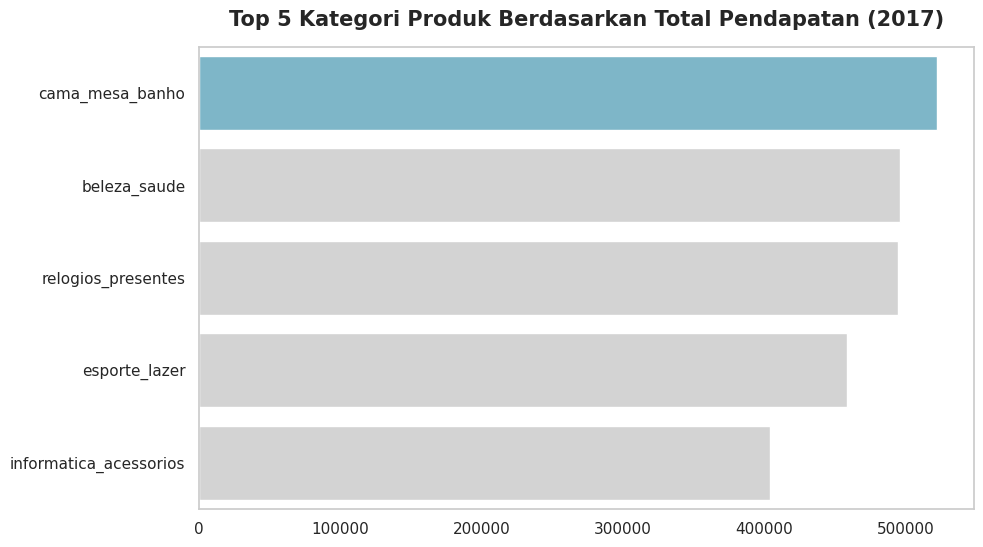

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur gaya grafik
sns.set_theme(style="whitegrid")

# Membuat grafik batang
plt.figure(figsize=(10, 6))
colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]
sns.barplot(
    x="price",
    y="product_category_name",
    data=q1_result.head(5),
    palette=colors,
)
plt.title("Top 5 Kategori Produk Berdasarkan Total Pendapatan (2017)", loc="center", fontsize=15, fontweight="semibold", pad=15)
plt.xlabel(None)
plt.ylabel(None)
plt.grid(False)
plt.show()

### Pertanyaan 2:

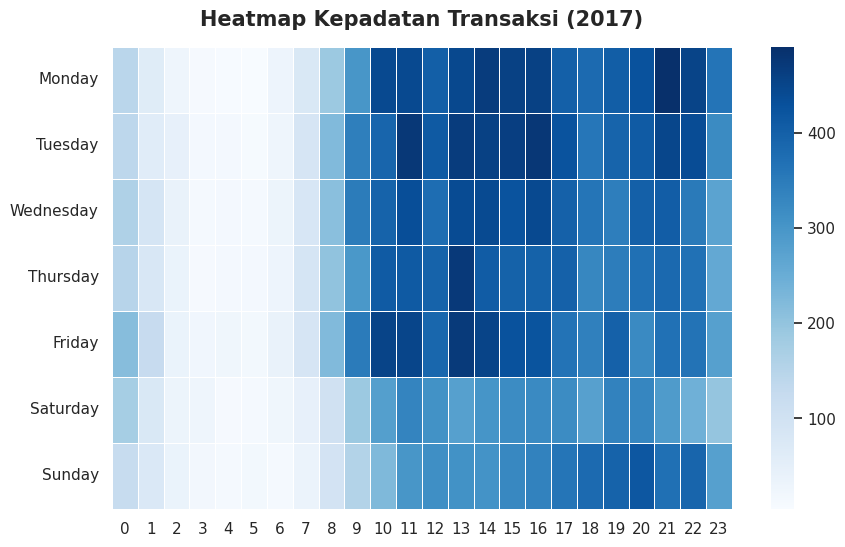

/tmp/ipykernel_2739/3686526631.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_2739/3686526631.py:30: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.barplot(


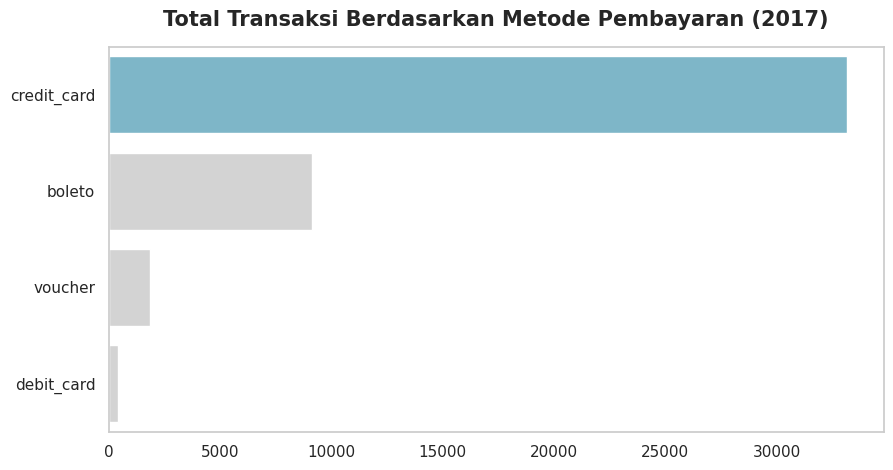

In [15]:
# Mengatur gaya grafik
sns.set_theme(style="whitegrid")

# Grafik 1: Heatmap untuk Waktu Optimal
plt.figure(figsize=(10, 6))
colors = "#4169E1"

# Menggunakan data 2017 untuk mencari kepadatan waktu
time_pivot = df_2017.groupby(['order_day', 'order_hour']) ['order_id'].nunique().unstack()
time_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
time_pivot = time_pivot.reindex(time_days)

sns.heatmap(
    time_pivot,
    cmap="Blues",
    linewidths=.5
)

plt.title("Heatmap Kepadatan Transaksi (2017)", fontsize=15, fontweight="bold", pad=15)
plt.xlabel(None)
plt.ylabel(None)
plt.show()
print("\n" * 2)

# Grafik 2: Metode Pembayaran
plt.figure(figsize=(10, 5))
colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]
payment_plot = df_2017.groupby('payment_type') ['order_id'].nunique().sort_values(ascending=False)

sns.barplot(
    x=payment_plot.values,
    y=payment_plot.index,
    palette=colors,
)
plt.title("Total Transaksi Berdasarkan Metode Pembayaran (2017)", fontsize=15, fontweight="bold", pad=15)
plt.xlabel(None)
plt.ylabel(None)
plt.grid(False)
plt.show()

### Pertanyaan 3:

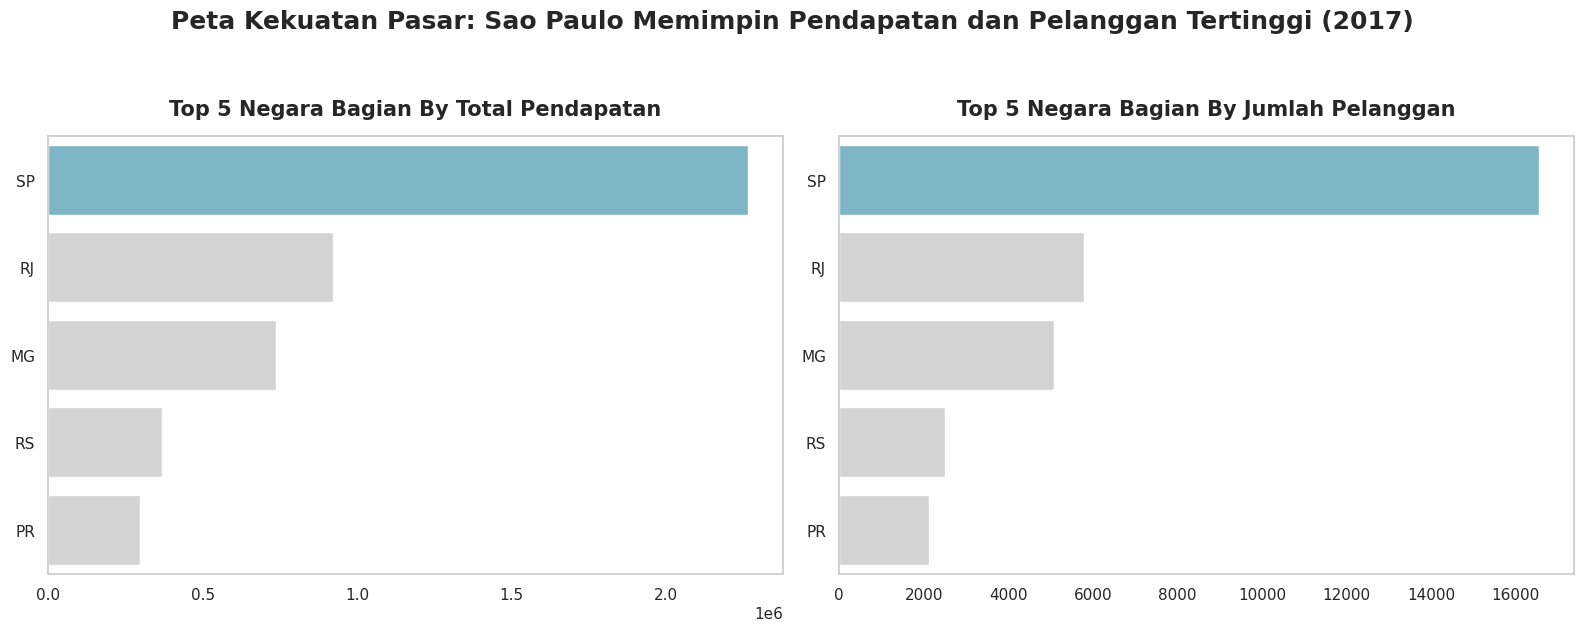

In [11]:
# Mengatur gaya grafik
sns.set_theme(style="whitegrid")

# Mengambil Top 5 data dari hasil EDA sebelumnya
top5_state = q3_result.head(5)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))
colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

# KOTAK KIRI: Grafik Total Pendapatan
ax1 = sns.barplot(
    x='price',
    y='customer_state',
    data=top5_state,
    palette=colors,
    ax=ax[0],
    hue='customer_state',
    legend=False
)
ax[0].set_title("Top 5 Negara Bagian By Total Pendapatan", fontsize=15, fontweight="bold", pad=15)
ax[0].set_xlabel(None)
ax[0].set_ylabel(None)
ax[0].grid(False)

# KOTAK KANAN: Grafik Jumlah Pelanggan
ax2 = sns.barplot(
    x='customer_unique_id',
    y='customer_state',
    data=top5_state,
    palette=colors,
    ax=ax[1],
    hue='customer_state',
    legend=False
)
ax[1].set_title("Top 5 Negara Bagian By Jumlah Pelanggan", fontsize=15, fontweight="bold", pad=15)
ax[1].set_xlabel(None)
ax[1].set_ylabel(None)
ax[1].grid(False)

plt.suptitle("Peta Kekuatan Pasar: Sao Paulo Memimpin Pendapatan dan Pelanggan Tertinggi (2017)", fontsize=18, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

**Insight:** (Opsional)

* **Pertanyaan 1:** Kategori `cama_mesa_banho` menjadi primadona penjualan dan penyumbang pendapatan tertinggi perusahaan (mencapai >521 ribu).
* **Pertanyaan 2:** Puncak kepadatan transaksi terjadi pada hari Selasa (14:00-16:00) dan Senin (21:00), dengan mayoritas mutlak pelanggan menggunakan kartu kredit.
* **Pertanyaan 3:** Negara bagian Sao Paulo mendominasi pasar secara drastis sebagai lumbung pendapatan utama (menyumbang >16 ribu pelanggan dan >2,26 juta pendapatan).

## Analisis Lanjutan (Opsional)

In [12]:
# 1. Menentukan Tanggal Snapshot
# Ambil tanggal transaksi terakhir di tahun 2017 + 1 hari
snapshot_date = df_2017['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# 2. Menghitung Recency, Frequency, dan Monetary
rfm_df = df_2017.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'nunique',
    'price': 'sum'
}).reset_index()

rfm_df.columns = ['customer_unique_id', 'Recency', 'Frequency', 'Monetary']
display(rfm_df.sort_values(by=['Frequency', 'Monetary'], ascending=[False, False]).head(10))

,customer_unique_id,Recency,Frequency,Monetary
23188,8d50f5eadf50201ccdcedfb9e2ac8455,40,8,371.56
3161,12f5d6e1cbf93dafd9dcc19095df0b3d,361,6,58.40
11854,47c1a3033b8b77b3ab6e109eb4d5fdf3,35,5,784.60
36372,dc813062e0fc23409cd255f7f53c7074,37,5,612.86
4528,1b6c7548a2a1f9037c1fd3ddfed95f33,12,5,533.22
16583,6469f99c1f9dfae7733b25662e7f1782,7,5,514.50
40029,f34cd7fd85a1f8baff886edf09567be3,100,4,1047.00
27544,a7657330b1c135f3acd420326e335b2c,55,4,689.46
10258,3e43e6105506432c953e165fb2acf44c,31,4,551.97
38954,ec7f1811826ab04a27a92197bc40c888,13,4,487.89


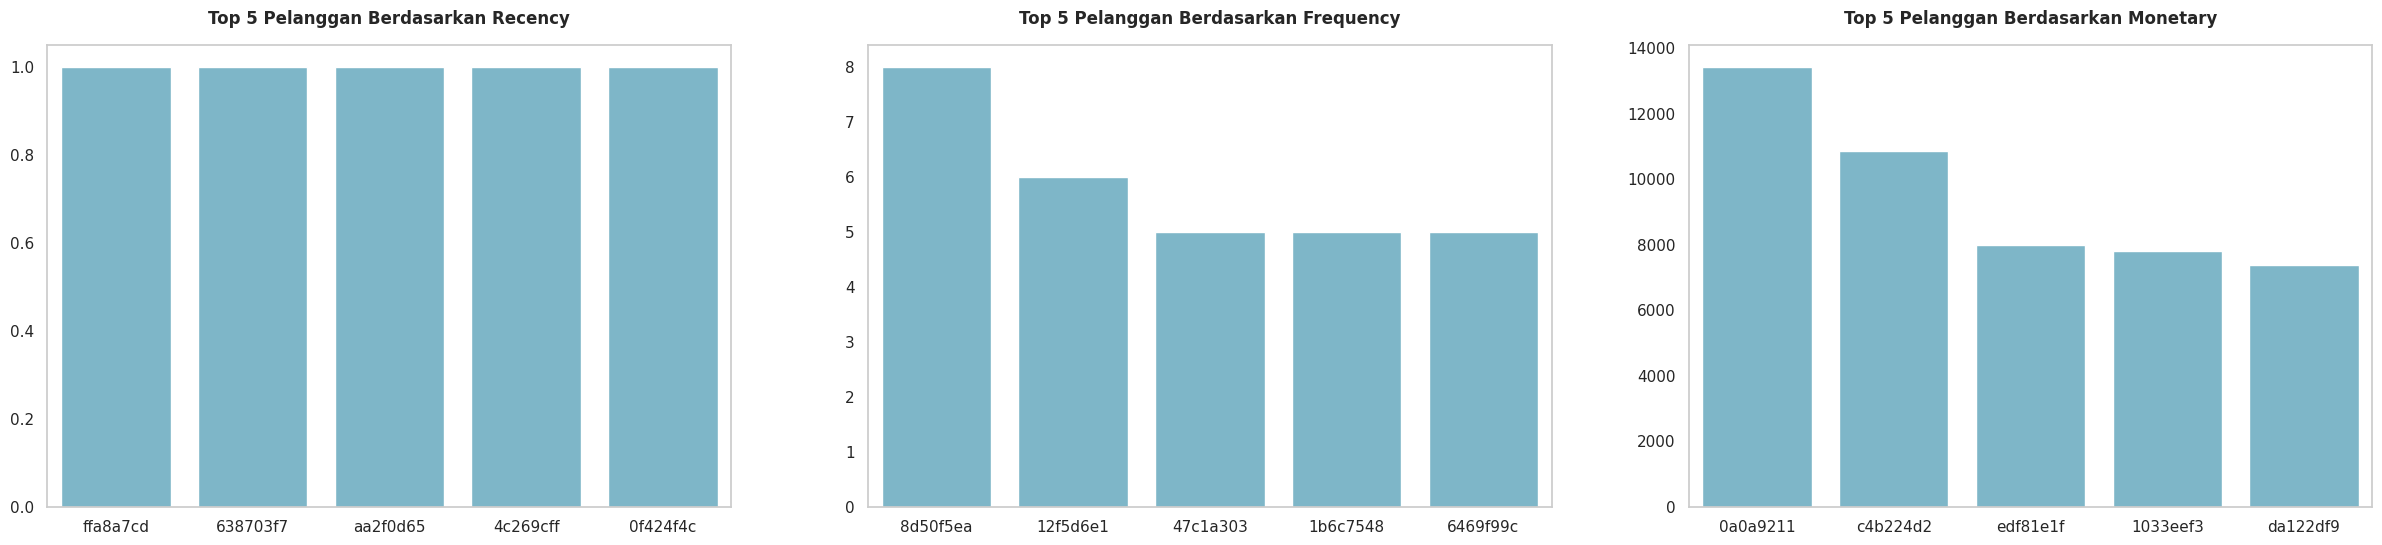

In [13]:
# VISUALISASI HASIL RFM (TOP 5 PELANGGAN)
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 6))
sns.set_theme(style="white")
color = "#72BCD4"

# Mengambil Top 5 untuk masing-masing kategori
top_recency = rfm_df.sort_values(by='Recency', ascending=True).head(5)
top_frequency = rfm_df.sort_values(by='Frequency', ascending=False).head(5)
top_monetary = rfm_df.sort_values(by='Monetary', ascending=False).head(5)

# Menyingkat ID Pelanggan agar rapi di grafik
top_recency['short_id'] = top_recency['customer_unique_id'].str[:8]
top_frequency['short_id'] = top_frequency['customer_unique_id'].str[:8]
top_monetary['short_id'] = top_monetary['customer_unique_id'].str[:8]

# Plot 1: Recency
sns.barplot(y='Recency', x='short_id', data=top_recency, color=color, ax=ax[0])
ax[0].set_title("Top 5 Pelanggan Berdasarkan Recency", fontsize=12, fontweight="bold", pad=15)
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].grid(False)

# Plot 2: Frequency
sns.barplot(y='Frequency', x='short_id', data=top_frequency, color=color, ax=ax[1])
ax[1].set_title("Top 5 Pelanggan Berdasarkan Frequency", fontsize=12, fontweight="bold", pad=15)
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].grid(False)

# Plot 3: Monetary
sns.barplot(y='Monetary', x='short_id', data=top_monetary, color=color, ax=ax[2])
ax[2].set_title("Top 5 Pelanggan Berdasarkan Monetary", fontsize=12, fontweight="bold", pad=15)
ax[2].set_ylabel(None)
ax[2].set_xlabel(None)
ax[2].grid(False)

**Insight:** (Opsional)
*   **Recency:** Terdapat pelanggan yang sangat aktif, dibuktikan dengan kelompok Top 5 Recency yang melakukan transaksi terakhirnya tepat 1 hari sebelum periode analisis (tahun 2017) ditutup.
*   **Frequency:** Pelanggan paling loyal di tahun 2017 (ID: 8d50f5ea...) mencatatkan rekor 8 kali transaksi, menunjukkan adanya segmen pengguna yang sangat sering kembali berbelanja di *platform*.
*   **Monetary:** Menariknya, penyumbang pendapatan terbesar (ID: 0a0a9211... dengan pengeluaran >13.000) bukanlah pelanggan yang paling sering berbelanja. Hal ini menunjukkan adanya perilaku belanja tipe transaksi sedikit namun bernilai sangat besar.

## Conclusion & Recommendation

### Conclusion & Recommendation

* **Conclusion Pertanyaan 1:** Berdasarkan performa pendapatan tahun 2017, kategori produk yang terbukti paling laris dan menghasilkan omzet tertinggi (lebih dari 521 ribu) adalah **`cama_mesa_banho`**. Kategori ini mutlak harus dijadikan prioritas utama perusahaan untuk memastikan ketersediaan stok di gudang pada periode selanjutnya guna mencegah kehabisan barang.
* **Conclusion Pertanyaan 2:** Pola transaksi pelanggan di tahun 2017 menunjukkan bahwa waktu yang paling optimal untuk meluncurkan promosi adalah pada **hari Selasa jam 14:00 - 16:00** (puncak transaksi siang) dan **hari Senin jam 21:00** (puncak transaksi malam). Untuk metode pembayaran, Kartu Kredit mendominasi pasar secara absolut (menyumbang lebih dari 33 ribu transaksi), sehingga metode ini harus menjadi prioritas utama sebagai syarat atau jalur promosi kampanye berikutnya.
* **Conclusion Pertanyaan 3:** Berdasarkan data demografi tahun 2017, **Sao Paulo** adalah negara bagian yang menyumbang jumlah pelanggan tertinggi (>16.500 pelanggan) sekaligus mencetak total pendapatan tertinggi yang teramat jauh di atas wilayah lain (menembus 2,26 juta). Fakta ini meresmikan SP sebagai lumbung pasar terkuat yang wajib menjadi target nomor satu untuk ekspansi pemasaran dan pembangunan infrastruktur layanan logistik perusahaan.

**Rekomendasi Action Item:**

Berdasarkan kesimpulan dari ketiga pertanyaan bisnis di atas, berikut adalah langkah konkret yang direkomendasikan untuk dieksekusi perusahaan:

1. **Strategi Persediaan & Promo Spesifik:** Tim *Marketing* dan *Inventory* harus berkolaborasi untuk merancang *Flash Sale* khusus produk kategori `cama_mesa_banho`. Promo ini wajib dijadwalkan secara rutin setiap hari Selasa pukul 14:00, dengan penawaran "Diskon Tambahan atau Cicilan 0% Khusus Pengguna Kartu Kredit". Pastikan stok barang `cama_mesa_banho` selalu ditambah 20-30% dari rata-rata penjualan sebelum *Flash Sale* dimulai.
2. **Optimalisasi Logistik di Zona VIP:** Karena pelanggan di Sao Paulo adalah penyumbang pendapatan terbesar yang gemar bertransaksi via kartu kredit, perusahaan sangat disarankan untuk membangun *Fulfillment Center* tambahan secara fisik di wilayah Sao Paulo. Tujuannya adalah untuk menjamin layanan pengiriman 24 Jam khusus bagi warga SP, sehingga loyalitas pasar terbesar Olist ini tetap terkunci dan tidak direbut kompetitor.

In [14]:
all_df.to_csv("main_data.csv", index=False)